
# Lab 6: FEM 1D

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import numpy.linalg as la
import scipy.integrate as integrate
from scipy import interpolate


### Exercise 1: Use FEM 1D to solve the EDO

Use FEM to solve the next EDO (improve the code seen in class). Compare with the analytical solution for some N elements.

\begin{equation}
-\dfrac{d^2y}{dx^2}=xe^x\,,\text{with}\; y(0)=(3-e)  \;, y(1)=0
\end{equation}


* Build a general scrip to solve a PDE of order two with Dirichlet's conditions: $y(a), y(b), x\,\epsilon\, [a,b]$. Use the method seen in class.

Nota: Solving the Green's function for this particular case we are able to find the analytical solution:
\begin{equation}
y(x) = 1-e-e^x(x-2)-x
\end{equation}

Ecuación Diferencial y Método de Elementos Finitos

**Ecuación:**
$$-\frac{d^2y}{dx^2} = x e^x, \quad \text{con } y(0) = (3 - e), \quad y(1) = 0$$

---

Método de Elementos Finitos

$$-\int_0^1 \frac{d^2y}{dx^2} \phi(x) \, dx = \int_0^1 x e^x \phi(x) \, dx \implies \int_0^1 \frac{dy}{dx} \frac{d\phi(x)}{dx} \, dx - \left. \phi(x) \frac{dy}{dx} \right|_0^1 = \int_0^1 x e^x \, dx, \quad \text{con } \phi(0) = \phi(1) = 0$$

Si $y(x) = \sum_{j=0}^{N-1} \alpha_j \phi_j(x)$ y utilizando:

$$\phi_i(x) = 
\begin{cases} 
0 & x < x_{i-1} \lor x > x_{i+1} \\
\frac{x - x_{i-1}}{h_i} & x_{i-1} \le x \le x_i \\
\frac{x_{i+1} - x}{h_i} & x_i < x \le x_{i+1} 
\end{cases}
\quad \text{donde } h_i = x_{i+1} - x_i, \quad \phi_i(x_i) = 1$$

Si $y(x) = \sum_{j=0}^{N-1} \alpha_j \phi_j(x_i) = \alpha_i \implies y(x) = \sum_{j=0}^{N-1} y(x_j) \phi_j(x)$

$$\int_0^1 \frac{d}{dx} \left( \sum_{j=0}^{N-1} y(x_j) \phi_j(x) \right) \frac{d\phi}{dx} \, dx = \int_0^1 x e^x \phi_i \, dx$$

Entonces para cada fila $i$, $\phi(x) = \phi_0(x), \dots, \phi_{N-1}$ se obtiene $N$ ecuaciones lineales para $\alpha_j$:

$$\int_a^b \left(\frac{d\phi_i}{dx}\right) \frac{d}{dx} \left( \sum_{j=0}^{N-1} \alpha_j \phi_j(x) \right) \, dx = \int_0^1 x e^x \phi_i \, dx, \quad i = 0, 1, \dots, N-1$$

Factorizando $\alpha_j$:

$$\begin{aligned}
\alpha_0 \int_0^1 \phi_0' \phi_0' \, dx + \alpha_1 \int_0^1 \phi_0' \phi_1' \, dx + \dots + \alpha_{N-1} \int_0^1 \phi_0' \phi_{N-1}' \, dx &= \int_0^1 x e^x \phi_0(x) \, dx \\
\alpha_0 \int_0^1 \phi_1' \phi_0' \, dx + \alpha_1 \int_0^1 \phi_1' \phi_1' \, dx + \dots + \alpha_{N-1} \int_0^1 \phi_1' \phi_{N-1}' \, dx &= \int_0^1 x e^x \phi_1(x) \, dx \\
&\vdots \\
\alpha_0 \int_0^1 \phi_{N-1}' \phi_0' \, dx + \alpha_1 \int_0^1 \phi_{N-1}' \phi_1' \, dx + \dots + \alpha_{N-1} \int_0^1 \phi_{N-1}' \phi_{N-1}' \, dx &= \int_0^1 x e^x \phi_{N-1}(x) \, dx
\end{aligned}$$

Que es igual a un **sistema matricial**: 

$$K \alpha = F$$

* **Componentes de $K$:** 
  $$k_{ij} = \int_0^1 \phi_i'(x) \phi_j'(x) \, dx$$

* **Componentes de $F$:** 
  $$F_i = \int_0^1 x e^x \phi_i(x) \, dx$$

---

Derivada de la Función Sombrero $\phi_i(x)$

Como $\phi_i(x)$ es una función sombrero, su derivada es:

* $x \in (x_{i-1}, x_i): \quad \phi_i(x) = \frac{x - x_{i-1}}{h_{i-1}} = \frac{x}{h_{i-1}} - \frac{x_{i-1}}{h_{i-1}} = \frac{1}{h_{i-1}}$
* $x \in (x_i, x_{i+1}): \quad \phi_i(x) = \frac{x_{i+1} - x}{h_i} = \frac{x_{i+1}}{h_i} - \frac{x}{h_i} = -\frac{1}{h_i}$
* $x \notin (x_{i-1}, x_{i+1}): \quad \phi_i(x) = 0$

Luego, para $\phi_{i+1}$:

$$\phi'_i = \begin{cases}
0 & x < x_{i-1} \lor x > x_{i+1} \\
\frac{1}{h_{i-1}} & x_{i-1} \le x \le x_i \\
-\frac{1}{h_i} & x_i \le x \le x_{i+1}
\end{cases}$$

> **Nota:** Para mallas uniformes: $h_{i-1} = h_i = h_{i+1} = h_1 = h_2 = \dots = h_n = h$

---

Cálculo de la Matriz $K$

* **Diagonal Principal ($i = j$):**
  $$K_{i,i} = \int_{x_{i-1}}^{x_i} \left(\frac{1}{h_{i-1}}\right)^2 \, dx + \int_{x_i}^{x_{i+1}} \left(-\frac{1}{h_i}\right)^2 \, dx = \frac{1}{h_{i-1}} + \frac{1}{h_i} = \frac{2}{h}$$
  $$\implies K_{i+1, i+1} = \int_{x_i}^{x_{i+2}} (\phi'_{i+1})^2 = \frac{1}{h_i} + \frac{1}{h_{i+1}}$$

* **Vecinos Inmediatos ($j = i+1$ o $j = i-1$):**
  $$K_{i, i+1} = \int_{x_i}^{x_{i+1}} \left(-\frac{1}{h_i}\right) \left(\frac{1}{h_i}\right) \, dx = \int_{x_i}^{x_{i+1}} -\frac{1}{h_i^2} \, dx = -\frac{1}{h_i}$$

* **Nodos Lejanos ($|j > i+1|$ o $j < i-1$):**
  $$\text{Dom}(\phi_i(x)) \cap \text{Dom}(\phi_j(x)) = \emptyset \implies K_{i,j} = 0$$

---

Por otro lado: Cálculo del Vector $F$

$$F_i = \int_0^1 x e^x \phi_i(x) \implies F_i = \int_{x_{i-1}}^{x_i} x e^x \left(\frac{x - x_{i-1}}{h}\right) \, dx + \int_{x_i}^{x_{i+1}} x e^x \left(\frac{x_{i+1} - x}{h}\right) \, dx$$

$$\frac{1}{h} \begin{pmatrix} 1 & -1 & 0 & \dots & 0 \\ -1 & 2 & -1 & \dots & 0 \\ 0 & -1 & 2 & \dots & 0 \\ \vdots & \vdots & \vdots & \ddots & \vdots \\ 0 & 0 & \dots & -1 & 1 \end{pmatrix} \begin{pmatrix} K_0 \\ \alpha_1 \\ \alpha_2 \\ \vdots \\ \alpha_{N-1} \end{pmatrix} = \begin{pmatrix} F_0 \\ F_1 \\ F_2 \\ \vdots \\ F_{N-1} \end{pmatrix}$$

> **Nota:** $K_{0,0} = \int_0^1 (\phi'_0(x))^2 \, dx$, es decir, $\phi_0(x) = \frac{x_1 - x}{h} \implies \phi'_0 = -\frac{1}{h}$  
> $K_{0,0} = \int_{x_0}^{x_1} \left(-\frac{1}{h}\right)^2 \, dx = \frac{1}{h}$ *(cae de 1 a 0)*

---

Aplicación de Condiciones de Frontera

Luego como $\alpha_0 = y(0) = 3 - e$ y $\alpha_{N-1} = y(1) = 0$, entonces tendremos una matriz de $(N-2) \times (N-2)$:

* **En la fila 1:**
  $$\frac{1}{h} \left( -1(3 - e) + 2\alpha_1 - 1\alpha_2 \right) = F_1 \implies \frac{1}{h}(2\alpha_1 - 1\alpha_2) = F_1 + \frac{1}{h}(3 - e)$$

* **Similarmente en la fila $N-2$:**
  $$\frac{1}{h} \left( -1\alpha_{N-3} + 2\alpha_{N-2} - 1(0) \right) = F_{N-2} \implies \frac{1}{h}(-1\alpha_{N-3} + 2\alpha_{N-2}) = F_{N-2}$$

Sistema Resultante:

$$\frac{1}{h} \begin{pmatrix} 2 & -1 & 0 & \dots & 0 \\ -1 & 2 & -1 & \dots & 0 \\ 0 & -1 & 2 & \dots & 0 \\ \vdots & \vdots & \vdots & \ddots & \vdots \\ 0 & 0 & 0 & \dots & 2 \end{pmatrix} \begin{pmatrix} \alpha_1 \\ \alpha_2 \\ \vdots \\ \alpha_{N-2} \end{pmatrix} = \begin{pmatrix} F_1 + \frac{1}{h}(3 - e) \\ F_2 \\ \vdots \\ F_{N-2} \end{pmatrix}$$

In [ ]:
N = 5  # Número de Nodos
x_max = 1
x = np.linspace(0, x_max, N) # Entonces habra N-1 elementos
h = x[1] - x[0]

# Condiciones de Frontera
y_a = 3 - np.exp(1)
y_b = 0

In [3]:
K = np.zeros((N, N), dtype=float)
F = np.zeros(N, dtype=float)

In [4]:
def lin1(x, x1, x2):
    return (x - x1) / (x2 - x1)

def lin2(x, x1, x2):
    return (x2 - x) / (x2 - x1)

def f(x):
    return x * np.exp(x)

def int1(min_val, max_val):
    return integrate.quad(lambda x: f(x) * lin1(x, min_val, max_val), min_val, max_val)[0]

def int2(min_val, max_val):
    return integrate.quad(lambda x: f(x) * lin2(x, min_val, max_val), min_val, max_val)[0]

In [5]:
for i in range(N-1):
    K_e = (1.0 / h) * np.array([[ 1.0, -1.0],
                                [-1.0,  1.0]])
    K[i:i+2, i:i+2] += K_e

In [6]:
K

array([[ 4., -4.,  0.,  0.,  0.],
       [-4.,  8., -4.,  0.,  0.],
       [ 0., -4.,  8., -4.,  0.],
       [ 0.,  0., -4.,  8., -4.],
       [ 0.,  0.,  0., -4.,  4.]])

In [7]:
for i in range(1, N):
    F[i-1] += int2(x[i-1], x[i])
    F[i]   += int1(x[i-1], x[i])    

In [ ]:
# Restar la condición de frontera a los nodos vecinos (1 y N-2)
F[1] -= K[1, 0] * y_a
F[N-2] -= K[N-2, N-1] * y_b

# Imponer las ecuaciones triviales en los bordes
K[0, :] = 0.0; K[0, 0] = 1.0; F[0] = y_a
K[N-1, :] = 0.0; K[N-1, N-1] = 1.0; F[N-1] = y_b

# Limpiar las acoplaciones de los extremos en la matriz
K[1, 0] = 0.0
K[N-2, N-1] = 0.0

u_fem = np.linalg.solve(K, F)

In [9]:
K

array([[ 1.,  0.,  0.,  0.,  0.],
       [ 0.,  8., -4.,  0.,  0.],
       [ 0., -4.,  8., -4.,  0.],
       [ 0.,  0., -4.,  8.,  0.],
       [ 0.,  0.,  0.,  0.,  1.]])

In [10]:
def y_analitica(val):
    return 1.0 - np.exp(1.0) - np.exp(val) * (val - 2.0) - val

u_exacta = y_analitica(x)

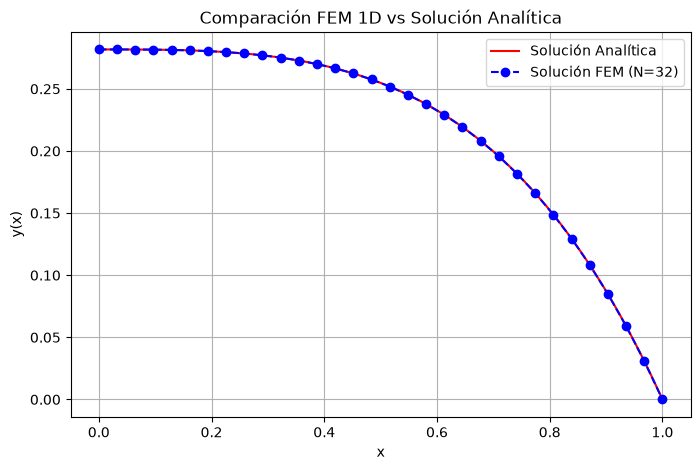

In [16]:
x_analitica = np.linspace(0,1,100)
plt.figure(figsize=(8, 5))
plt.plot(x_analitica, y_analitica(x_analitica), 'r-', label='Solución Analítica')
plt.plot(x, u_fem, 'bo--', label=f'Solución FEM (N={N})')
plt.xlabel('x')
plt.ylabel('y(x)')
plt.title('Comparación FEM 1D vs Solución Analítica')
plt.legend()
plt.grid(True)
plt.show()

In [22]:
lista_N = [5, 9, 17, 33]  # Nodos
x_fine = np.linspace(0, x_max, 300)
y_exacta_fine = y_analitica(x_fine)

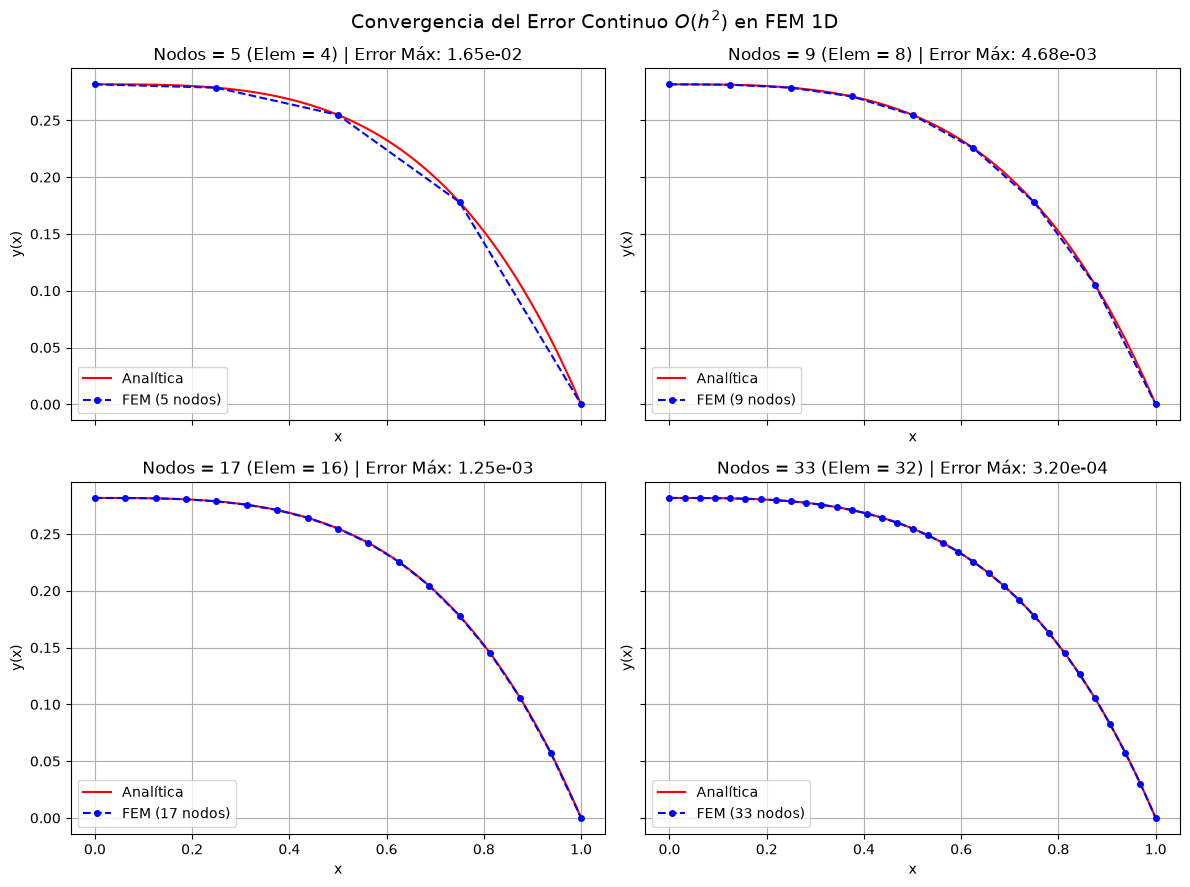

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True, sharey=True)
axes_flat = axes.flatten() 

for idx, N in enumerate(lista_N):
    ax = axes_flat[idx]

    num_elementos = N - 1
    x = np.linspace(0, x_max, N)
    h = x[1] - x[0]

    K = np.zeros((N, N), dtype=float)
    F = np.zeros(N, dtype=float)
    
    # Ensamblado
    for i in range(num_elementos):
        K_e = (1.0 / h) * np.array([[ 1.0, -1.0],
                                    [-1.0,  1.0]])
        K[i:i+2, i:i+2] += K_e

    for i in range(1, N):
        F[i-1] += int2(x[i-1], x[i])
        F[i]   += int1(x[i-1], x[i])

    F[1]   -= K[1, 0] * y_a
    F[N-2] -= K[N-2, N-1] * y_b

    K[0, :] = 0.0; K[0, 0] = 1.0; F[0] = y_a
    K[N-1, :] = 0.0; K[N-1, N-1] = 1.0; F[N-1] = y_b

    K[1, 0] = 0.0
    K[N-2, N-1] = 0.0

    u_fem = np.linalg.solve(K, F)
    
    # Interpolamos la solución discreta FEM
    u_fem_interp = np.interp(x_fine, x, u_fem)
    
    # Calculamos el error máximo 
    error_max_continuo = np.max(np.abs(u_fem_interp - y_exacta_fine))

    ax.plot(x_fine, y_exacta_fine, 'r-', linewidth=1.5, label='Analítica')
    ax.plot(x, u_fem, 'bo--', markersize=4, label=f'FEM ({N} nodos)')
    ax.set_title(f'Nodos = {N} (Elem = {num_elementos}) | Error Máx: {error_max_continuo:.2e}')
    ax.set_xlabel('x')
    ax.set_ylabel('y(x)')
    ax.legend(loc='lower left')
    ax.grid(True)

plt.suptitle('Convergencia del Error Continuo $O(h^2)$ en FEM 1D', fontsize=14)
plt.tight_layout()
plt.show()